RUNTIME: CPU (no GPU needed for this notebook)  
INSTRUCTIONS:

1. Set runtime to CPU: Runtime → Change runtime type → None
2. This notebook depends on results from all other notebooks being committed to results/ in the repo first
3. Run all cells in order: Runtime → Run all
4. When prompted, authorize Google Drive access
5. To save results/figures to GitHub:   
    a. Right-click the file in the left sidebar → Download  
    b. Go to the GitHub repo → results/ → Add file → Upload files   
    c. Commit directly on GitHub    
6. Save the notebook: Ctrl+S → save to GitHub when prompted

In [12]:
# ── 1. Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/cs4120_project/"

# ── 2. Standard imports ───────────────────────────────────────────────────────
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import f1_score, classification_report

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 12})
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# clone repo and move into notebook working directory
!git clone https://github.com/phisomni-edu/cs4120-project /content/cs4120-project
%cd /content/cs4120-project/notebooks

fatal: destination path '/content/cs4120-project' already exists and is not an empty directory.
/content/cs4120-project/notebooks


## 2. Setup Paths
Resolve repository paths to ensure data and results directories load correctly.

In [14]:
# ── 4. Resolve paths ──────────────────────────────────────────────────────────
RESULTS_DIR = Path("/content/cs4120-project/results")
FIG_DIR     = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Results dir: ", RESULTS_DIR)
print("Figures dir: ", FIG_DIR)

Results dir:  /content/cs4120-project/results
Figures dir:  /content/cs4120-project/results/figures


## 3. Visualizations
Load results CSVs and generate all figures. Re-run this section once BERT results are committed.

In [15]:
# ── 5. Load results CSVs ──────────────────────────────────────────────────────
def load_overall(name):
    p = RESULTS_DIR / f"{name}_overall.csv"
    if p.exists(): return pd.read_csv(p)
    print(f"[WARNING] Missing: {name}_overall.csv"); return None

def load_per_class(name):
    p = RESULTS_DIR / f"{name}_per_class.csv"
    if p.exists(): return pd.read_csv(p)
    print(f"[WARNING] Missing: {name}_per_class.csv"); return None

svm_overall      = load_overall("svm_tfidf")
svm_per_class    = load_per_class("svm_tfidf")
setfit_overall   = load_overall("setfit")
setfit_per_class = load_per_class("setfit")
zs_overall       = load_overall("zero_shot")
zs_per_class     = load_per_class("zero_shot")
bert_overall     = load_overall("distilbert")
bert_per_class   = load_per_class("distilbert")

print("Loaded:", [n for n, d in [("svm", svm_overall), ("setfit", setfit_overall),
                                  ("zero_shot", zs_overall), ("distilbert", bert_overall)] if d is not None])

MODEL_COLORS = {
    "SVM (TF-IDF)": "#2196F3",
    "SetFit":        "#FF9800",
    "BERT":          "#4CAF50",
    "Zero-Shot":     "#9C27B0",
}

def avg_seeds(df, group_cols, value_cols):
    return df.groupby(group_cols)[value_cols].mean().reset_index()

def per_class_f1(df, fraction):
    sub = df[df["data_fraction"] == fraction]
    return avg_seeds(sub, ["emotion"], ["f1"]).set_index("emotion")["f1"]

Loaded: ['svm', 'setfit', 'zero_shot', 'distilbert']


### 3.1 Figure 1: Learning Curves (Macro F1 vs. Data Fraction)

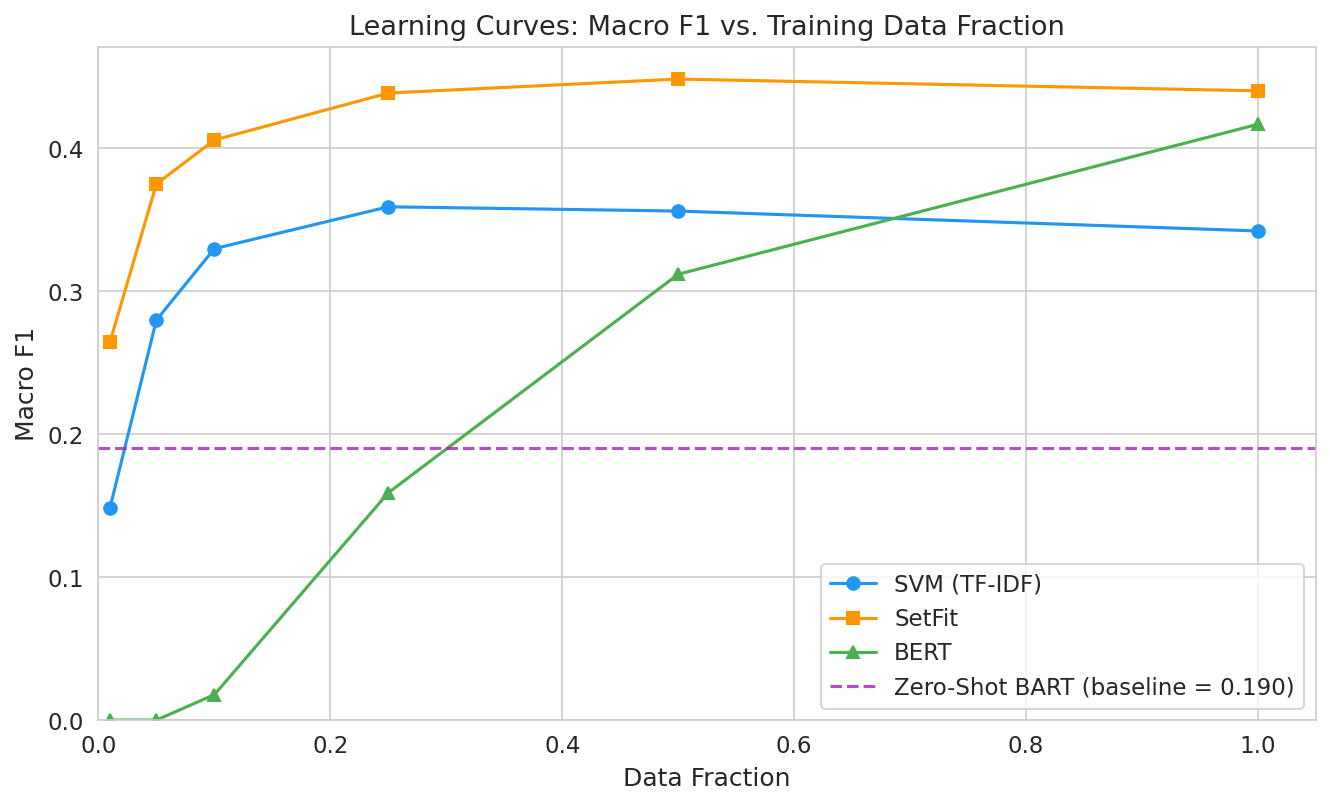

In [16]:
# plot macro-f1 learning curves across methods and save figure
fig, ax = plt.subplots(figsize=(9, 5.5))

if svm_overall is not None:
    s = avg_seeds(svm_overall, ["data_fraction"], ["macro_f1"])
    ax.plot(s["data_fraction"], s["macro_f1"], marker="o",
            label="SVM (TF-IDF)", color=MODEL_COLORS["SVM (TF-IDF)"])

if setfit_overall is not None:
    s = avg_seeds(setfit_overall, ["data_fraction"], ["macro_f1"])
    ax.plot(s["data_fraction"], s["macro_f1"], marker="s",
            label="SetFit", color=MODEL_COLORS["SetFit"])

if bert_overall is not None:
    s = avg_seeds(bert_overall, ["data_fraction"], ["macro_f1"])
    ax.plot(s["data_fraction"], s["macro_f1"], marker="^",
            label="BERT", color=MODEL_COLORS["BERT"])

if zs_overall is not None:
    zs_f1 = zs_overall["macro_f1"].mean()
    ax.axhline(zs_f1, linestyle="--", color=MODEL_COLORS["Zero-Shot"],
               label=f"Zero-Shot BART (baseline = {zs_f1:.3f})", alpha=0.8)

ax.set_xlabel("Data Fraction")
ax.set_ylabel("Macro F1")
ax.set_title("Learning Curves: Macro F1 vs. Training Data Fraction")
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_learning_curves.png", bbox_inches="tight")
plt.show()

### 3.2 Figure 2: Per-Emotion Learning Curves (Selected Emotions)

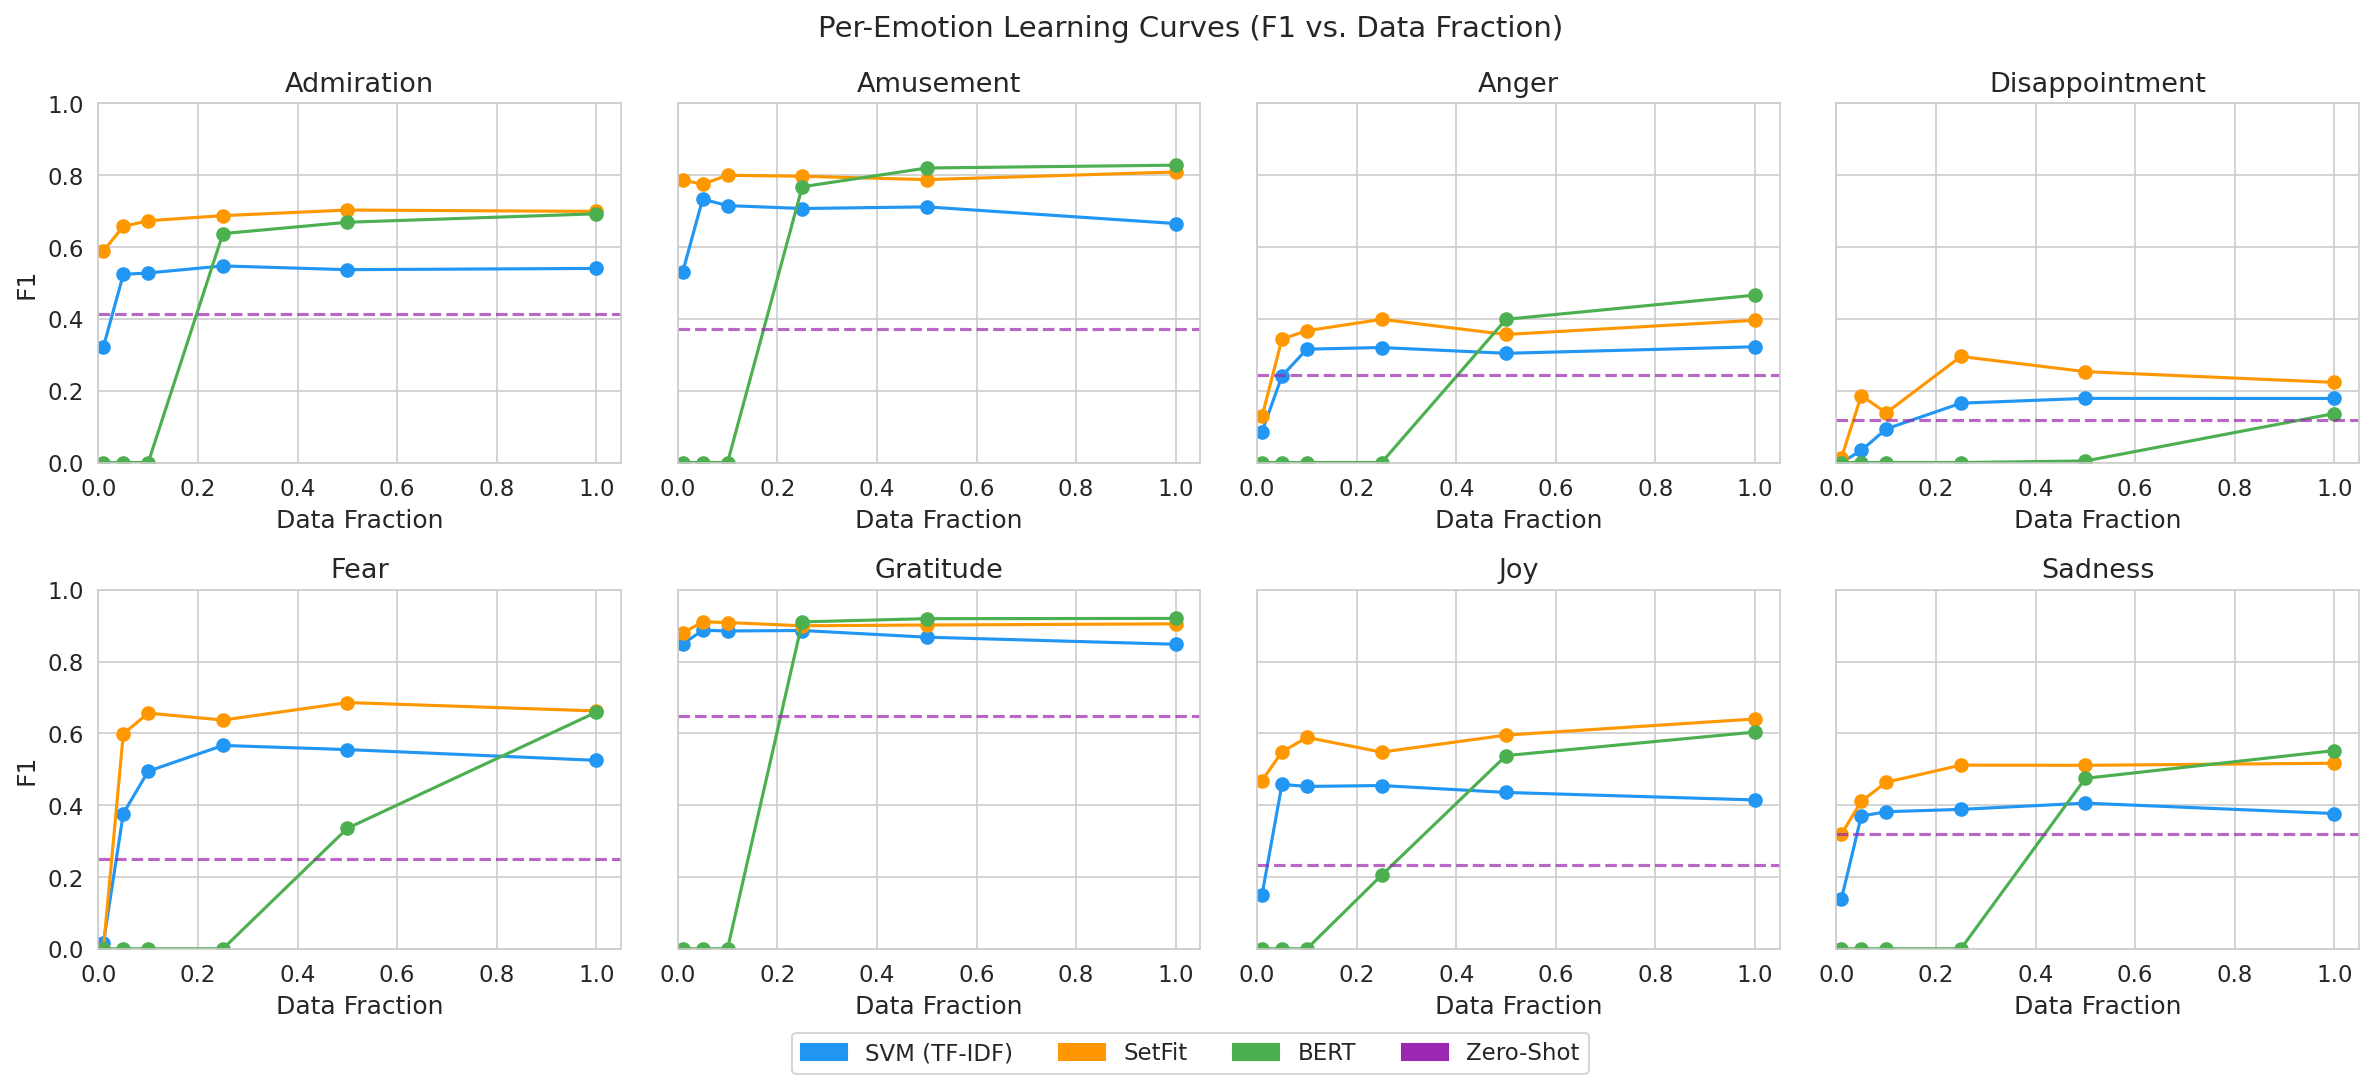

In [17]:
# compare per-emotion f1 trajectories at low and full data
SELECTED_EMOTIONS = [
    "admiration", "amusement", "anger", "disappointment",
    "fear", "gratitude", "joy", "sadness"
]

models_pc = [
    ("SVM (TF-IDF)", svm_per_class),
    ("SetFit",       setfit_per_class),
    ("BERT",         bert_per_class),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
for ax, emotion in zip(axes.flatten(), SELECTED_EMOTIONS):
    for model_name, df in models_pc:
        if df is None: continue
        sub = df[df["emotion"] == emotion]
        avg = avg_seeds(sub, ["data_fraction"], ["f1"])
        ax.plot(avg["data_fraction"], avg["f1"],
                marker="o", label=model_name, color=MODEL_COLORS[model_name])
    if zs_per_class is not None:
        zs_f1 = zs_per_class[zs_per_class["emotion"] == emotion]["f1"].mean()
        ax.axhline(zs_f1, linestyle="--", color=MODEL_COLORS["Zero-Shot"], alpha=0.7)
    ax.set_title(emotion.capitalize())
    ax.set_xlabel("Data Fraction")
    ax.set_ylim(0, 1); ax.set_xlim(left=0)

axes[0][0].set_ylabel("F1"); axes[1][0].set_ylabel("F1")
handles = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Per-Emotion Learning Curves (F1 vs. Data Fraction)", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_per_emotion_curves.png", bbox_inches="tight")
plt.show()

### 3.3 Figure 3: Per-Class F1 Heatmap (All Models at Key Fractions)

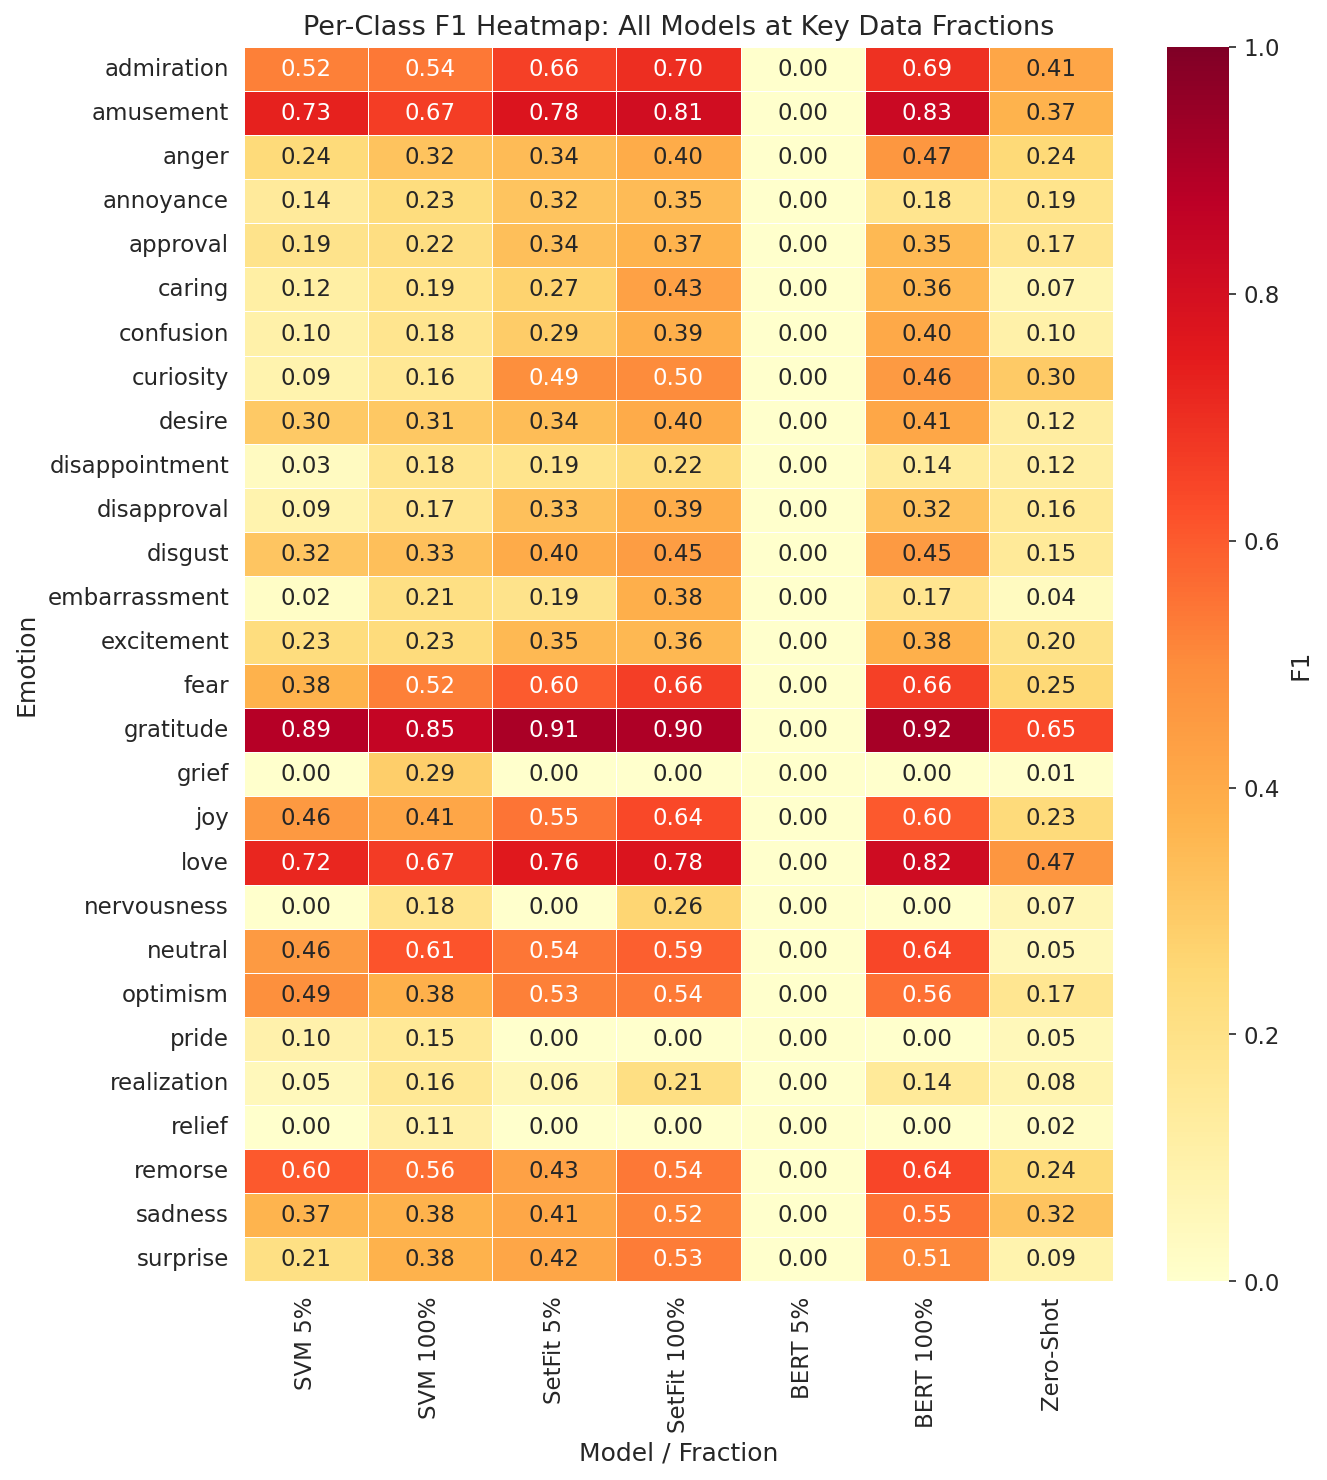

In [18]:
# assemble compact per-emotion comparison table
frames = []
if svm_per_class is not None:
    frames.append(per_class_f1(svm_per_class, 0.05).rename("SVM 5%"))
    frames.append(per_class_f1(svm_per_class, 1.0).rename("SVM 100%"))
if setfit_per_class is not None:
    frames.append(per_class_f1(setfit_per_class, 0.05).rename("SetFit 5%"))
    frames.append(per_class_f1(setfit_per_class, 1.0).rename("SetFit 100%"))
if bert_per_class is not None:
    frames.append(per_class_f1(bert_per_class, 0.05).rename("BERT 5%"))
    frames.append(per_class_f1(bert_per_class, 1.0).rename("BERT 100%"))
if zs_per_class is not None:
    frames.append(zs_per_class.groupby("emotion")["f1"].mean().rename("Zero-Shot"))

heatmap_df = pd.concat(frames, axis=1).sort_index()

fig, ax = plt.subplots(figsize=(max(8, len(heatmap_df.columns) * 1.3), 10))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.4, ax=ax, cbar_kws={"label": "F1"})
ax.set_title("Per-Class F1 Heatmap: All Models at Key Data Fractions")
ax.set_xlabel("Model / Fraction"); ax.set_ylabel("Emotion")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_heatmap.png", bbox_inches="tight")
plt.show()

### 3.4 Figure 4: Per-Class F1 Bar Charts (Low Data vs. Full Data)

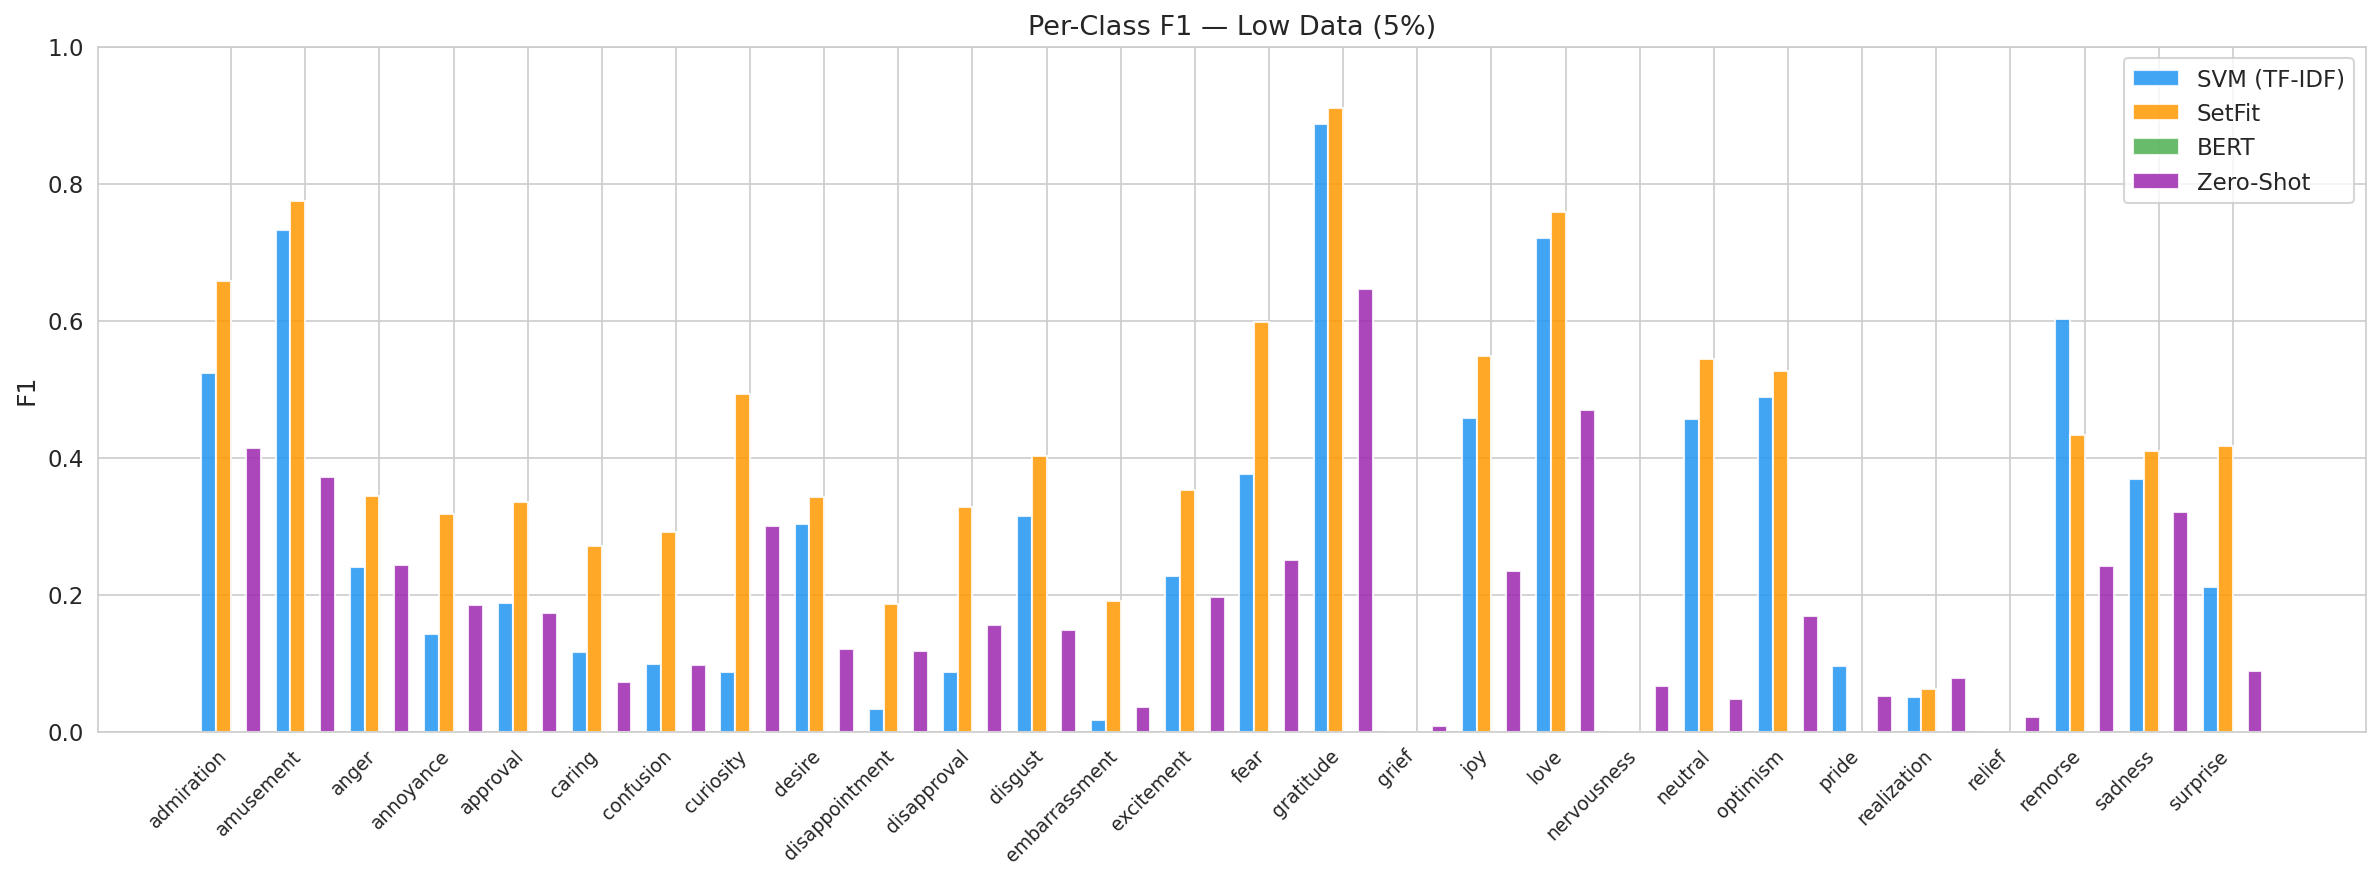

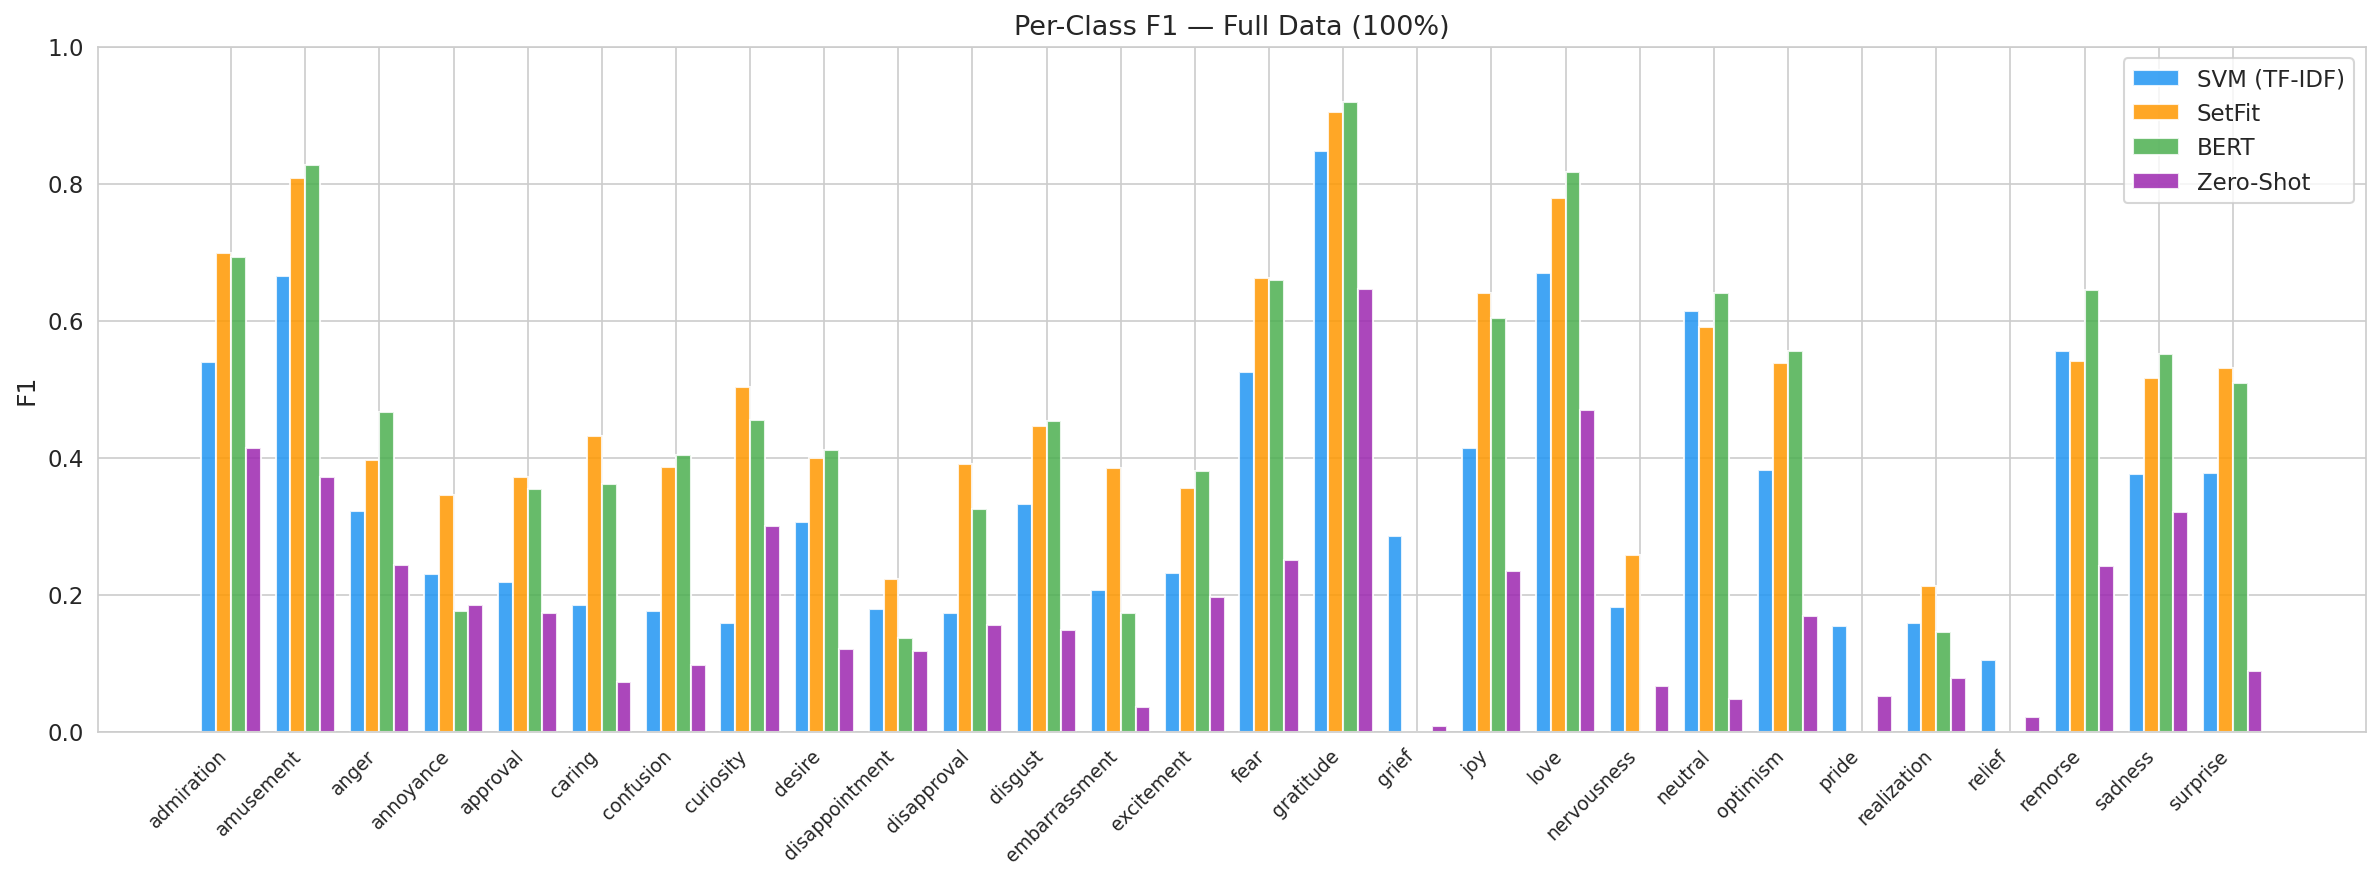

In [19]:
# define reusable grouped bar-chart helper for key fractions
def bar_chart(title, svm_frac, setfit_frac, bert_frac=None, fname=""):
    data = {}
    if svm_per_class is not None:
        data["SVM (TF-IDF)"] = per_class_f1(svm_per_class, svm_frac)
    if setfit_per_class is not None:
        data["SetFit"] = per_class_f1(setfit_per_class, setfit_frac)
    if bert_per_class is not None and bert_frac is not None:
        data["BERT"] = per_class_f1(bert_per_class, bert_frac)
    if zs_per_class is not None:
        data["Zero-Shot"] = zs_per_class.groupby("emotion")["f1"].mean()

    plot_df = pd.concat(data, axis=1).sort_index()
    x = np.arange(len(plot_df))
    n = len(plot_df.columns)
    width = 0.8 / n

    fig, ax = plt.subplots(figsize=(16, 6))
    for i, col in enumerate(plot_df.columns):
        offset = (i - n / 2 + 0.5) * width
        ax.bar(x + offset, plot_df[col], width,
               label=col, color=MODEL_COLORS[col], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("F1"); ax.set_ylim(0, 1)
    ax.set_title(f"Per-Class F1 — {title}")
    ax.legend(); plt.tight_layout()
    plt.savefig(FIG_DIR / fname, bbox_inches="tight")
    plt.show()

bar_chart("Low Data (5%)",    svm_frac=0.05, setfit_frac=0.05, bert_frac=0.05, fname="fig4a_bar_low.png")
bar_chart("Full Data (100%)", svm_frac=1.0,  setfit_frac=1.0,  bert_frac=1.0,  fname="fig4b_bar_full.png")

### 3.5 Figure 5: TP/FP/FN Breakdown per Emotion (SVM and Zero-Shot)

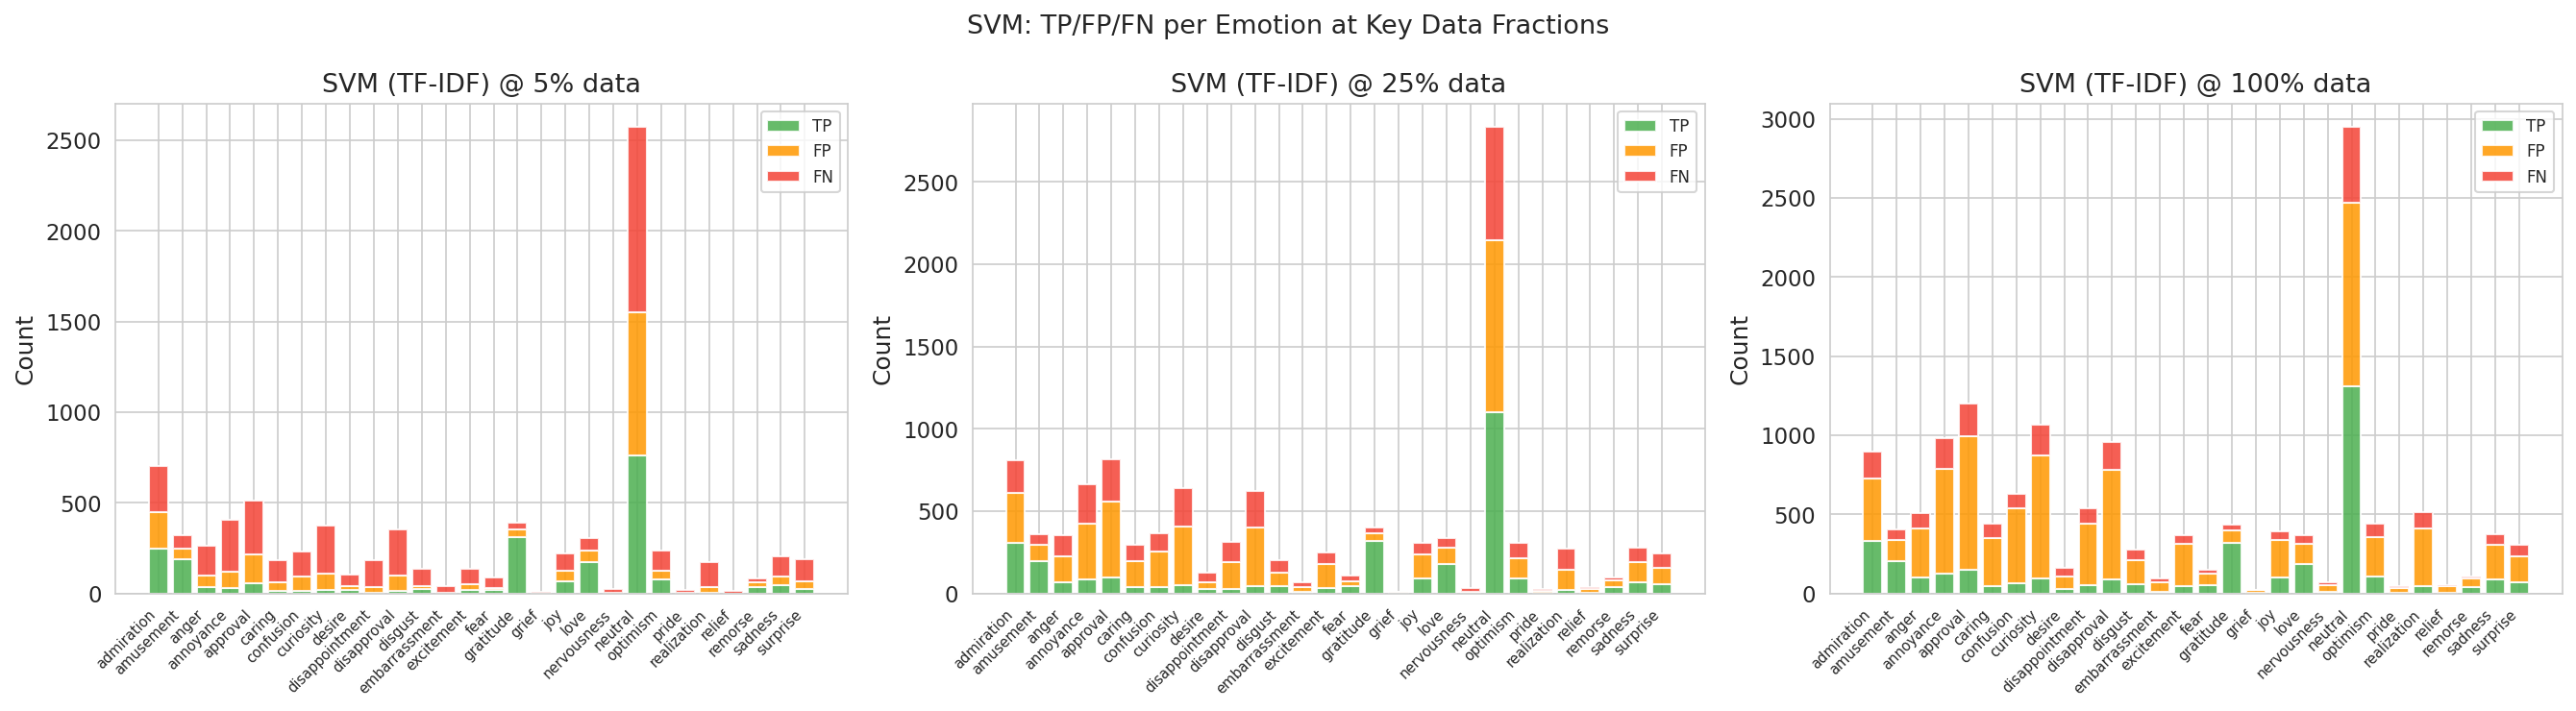

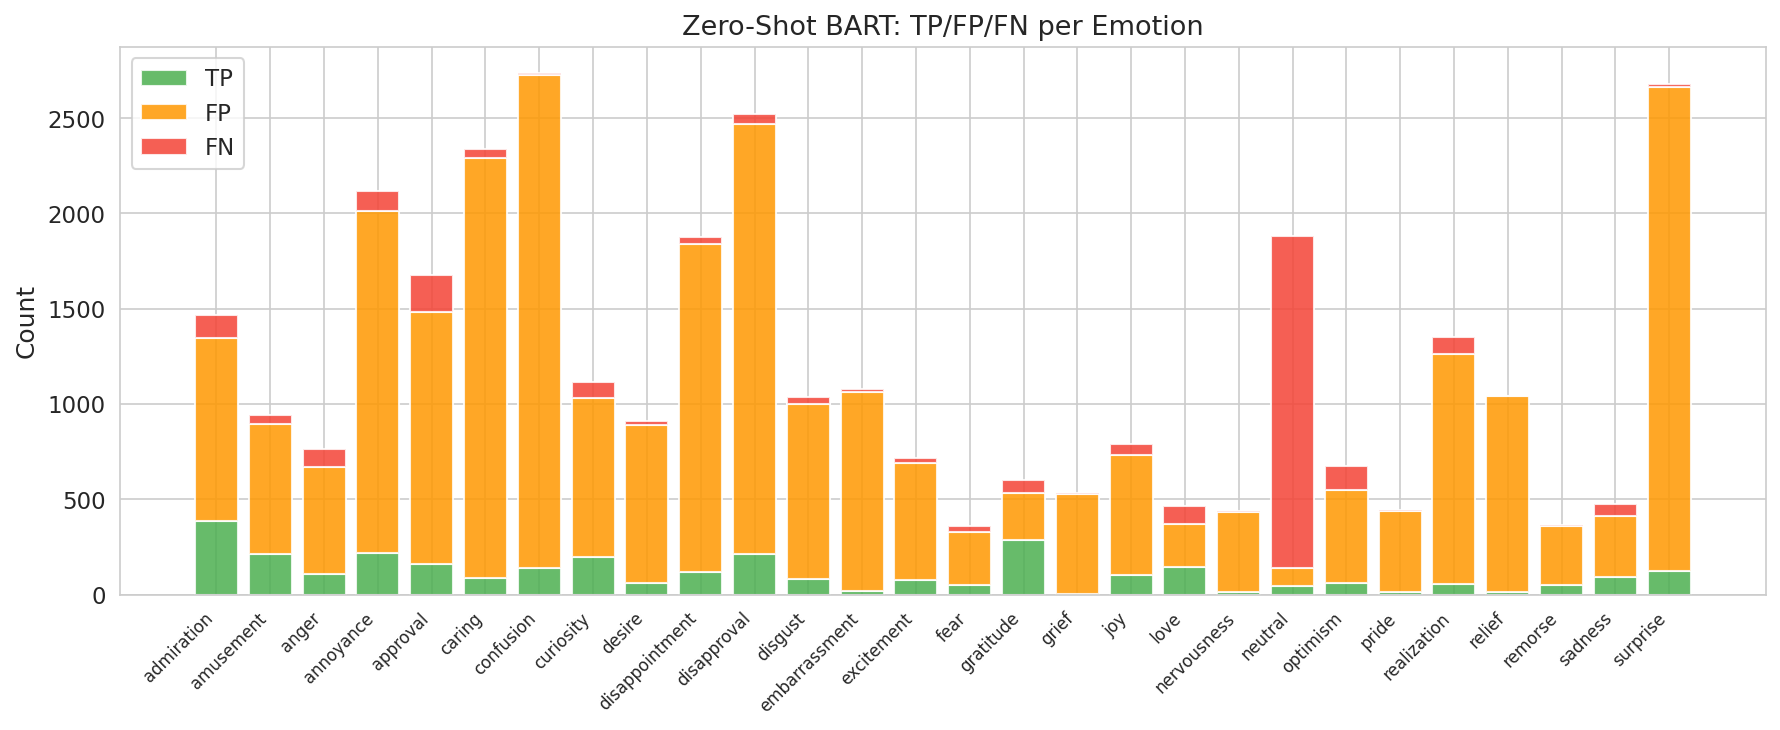

In [20]:
# plot stacked tp/fp/fn diagnostics by emotion for selected models
def tp_fp_fn_bars(per_class_df, model_name, fraction, ax):
    sub = per_class_df[per_class_df["data_fraction"] == fraction]
    g = sub.groupby("emotion")[["tp", "fp", "fn"]].mean().sort_index()
    x = np.arange(len(g))
    ax.bar(x, g["tp"], label="TP", color="#4CAF50", alpha=0.85)
    ax.bar(x, g["fp"], bottom=g["tp"], label="FP", color="#FF9800", alpha=0.85)
    ax.bar(x, g["fn"], bottom=g["tp"]+g["fp"], label="FN", color="#F44336", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(g.index, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{model_name} @ {int(fraction*100)}% data")
    ax.set_ylabel("Count"); ax.legend(fontsize=8)

if svm_per_class is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, frac in zip(axes, [0.05, 0.25, 1.0]):
        tp_fp_fn_bars(svm_per_class, "SVM (TF-IDF)", frac, ax)
    fig.suptitle("SVM: TP/FP/FN per Emotion at Key Data Fractions", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig5a_svm_breakdown.png", bbox_inches="tight")
    plt.show()

if zs_per_class is not None:
    fig, ax = plt.subplots(figsize=(12, 5))
    g = zs_per_class.groupby("emotion")[["tp", "fp", "fn"]].mean().sort_index()
    x = np.arange(len(g))
    ax.bar(x, g["tp"], label="TP", color="#4CAF50", alpha=0.85)
    ax.bar(x, g["fp"], bottom=g["tp"], label="FP", color="#FF9800", alpha=0.85)
    ax.bar(x, g["fn"], bottom=g["tp"]+g["fp"], label="FN", color="#F44336", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(g.index, rotation=45, ha="right", fontsize=8)
    ax.set_title("Zero-Shot BART: TP/FP/FN per Emotion")
    ax.set_ylabel("Count"); ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig5b_zeroshot_breakdown.png", bbox_inches="tight")
    plt.show()

### 3.6 Figure 6: Summary Table

In [21]:
# build summary table for major model/fraction checkpoints
rows = []
for name, df, fracs in [
    ("SVM (TF-IDF)", svm_overall,   [0.05, 1.0]),
    ("SetFit",       setfit_overall, [0.05, 1.0]),
    ("BERT",         bert_overall,   [0.05, 1.0]),
]:
    if df is None: continue
    for frac in fracs:
        sub = df[df["data_fraction"] == frac]
        rows.append({"Model": name, "Data Fraction": f"{int(frac*100)}%",
                     "Macro F1": round(sub["macro_f1"].mean(), 4),
                     "Accuracy": round(sub["accuracy"].mean(), 4)})

if zs_overall is not None:
    rows.append({"Model": "Zero-Shot BART", "Data Fraction": "N/A",
                 "Macro F1": round(zs_overall["macro_f1"].mean(), 4),
                 "Accuracy": round(zs_overall["accuracy"].mean(), 4)})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(FIG_DIR / "summary_table.csv", index=False)

         Model Data Fraction  Macro F1  Accuracy
  SVM (TF-IDF)            5%    0.2798    0.2628
  SVM (TF-IDF)          100%    0.3421    0.1443
        SetFit            5%    0.3750    0.3903
        SetFit          100%    0.4401    0.4443
          BERT            5%    0.0000    0.0000
          BERT          100%    0.4167    0.4610
Zero-Shot BART           N/A    0.1903    0.0074


In [22]:
# quick sanity check print for svm full-data rows
print(svm_overall[svm_overall["data_fraction"] == 1.0])

       method  data_fraction  seed  accuracy  macro_f1  micro_f1  hamming_loss
5   svm_tfidf            1.0     7  0.144279  0.342073  0.403183      0.072554
11  svm_tfidf            1.0    21  0.144279  0.342073  0.403183      0.072554
17  svm_tfidf            1.0    42  0.144279  0.342073  0.403183      0.072554
